In [18]:
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
# Data
luas_tanah = [60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165]
harga_jual = [455, 520, 590, 690, 760, 860, 935, 1030, 1110, 1215, 610, 655, 735, 820, 875, 990, 1045, 1185, 1285, 1365]


In [20]:
# Fungsi bantuan untuk menghitung mean dan standar deviasi (std)
def mean(values):
    return sum(values) / len(values)

def std(values):
    mean_val = mean(values)
    return (sum((x - mean_val) ** 2 for x in values) / len(values)) ** 0.5


In [21]:
# Menghitung rata-rata luas dan harga
mean_luas_tanah = mean(luas_tanah)
mean_harga_jual = mean(harga_jual)


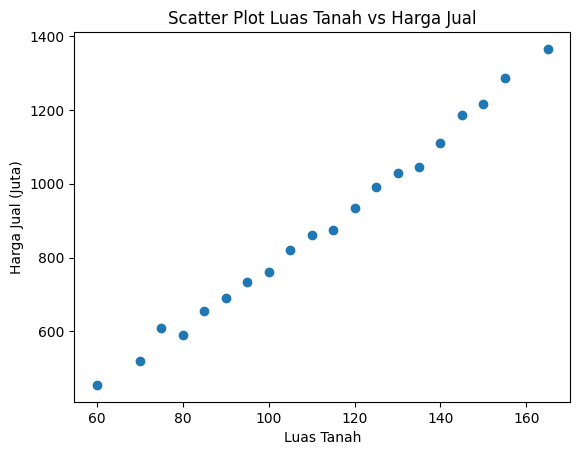

In [22]:

# Membuat scatter plot
plt.scatter(luas_tanah, harga_jual)
plt.title('Scatter Plot Luas Tanah vs Harga Jual')
plt.xlabel('Luas Tanah')
plt.ylabel('Harga Jual (Juta)')
plt.show()


In [23]:

# Menghitung korelasi
correlation = sum(
    (x - mean_luas_tanah) * (y - mean_harga_jual)
    for x, y in zip(luas_tanah, harga_jual)
) / (len(luas_tanah) * std(luas_tanah) * std(harga_jual))


# Mencetak korelasi
print("Korelasi antara Luas Tanah dan Harga Jual:", correlation)


Korelasi antara Luas Tanah dan Harga Jual: 0.9968583785220295


In [24]:

# Menghitung koefisien regresi (slope dan intercept)
numerator = sum(
    (x - mean_luas_tanah) * (y - mean_harga_jual)
    for x, y in zip(luas_tanah, harga_jual)
)

denominator = sum(
    (x - mean_luas_tanah) ** 2
    for x in luas_tanah
)

In [25]:
# Menghitung slope dan intercept
slope = numerator / denominator
intercept = mean_harga_jual - slope * mean_luas_tanah

In [26]:

# Fungsi untuk prediksi
def predict(x):
    return slope * x + intercept


In [27]:

# Mencetak hasil slope dan intercept
print("Slope (b1):", slope)
print("Intercept (b0):", intercept)


Slope (b1): 8.609929078014185
Intercept (b0): -82.11702127659578


In [28]:

# Fungsi untuk menghitung MAE, MSE, RMSE
def mae(predictions, targets):
    return sum(abs(p - t) for p, t in zip(predictions, targets)) / len(targets)

def mse(predictions, targets):
    return sum((p - t) ** 2 for p, t in zip(predictions, targets)) / len(targets)

def rmse(predictions, targets):
    return mse(predictions, targets) ** 0.5

In [29]:

# Membuat prediksi untuk setiap luas tanah
predictions = [predict(x) for x in luas_tanah]


In [30]:

# Menghitung MAE, MSE, dan RMSE
mae_value = mae(predictions, harga_jual)
mse_value = mse(predictions, harga_jual)
rmse_value = rmse(predictions, harga_jual)


In [31]:

# Menghitung R-squared
sst = sum((y - mean_harga_jual) ** 2 for y in harga_jual)
ssr = sum((p - y) ** 2 for p, y in zip(predictions, harga_jual))
r_squared_value = 1 - (ssr / sst)

In [32]:

# Mencetak hasil evaluasi
print("MAE:", mae_value)
print("MSE:", mse_value)
print("RMSE:", rmse_value)
print("R-squared:", r_squared_value)

MAE: 15.552836879432618
MSE: 412.41312056737587
RMSE: 20.307957075180553
R-squared: 0.9937266268295698


In [33]:

# Menambahkan hasil prediksi dan residu ke dataset
dataset = {
    "Luas_Tanah": luas_tanah,
    "Harga_Jual": harga_jual,
    "Prediksi_Harga": predictions,
    "Residu": [y - p for y, p in zip(harga_jual, predictions)]
}


In [17]:

# Membuat DataFrame
df_dataset = pd.DataFrame(dataset)

# Mencetak DataFrame
print(df_dataset)

    Luas_Tanah  Harga_Jual  Prediksi_Harga     Residu
0           60         455      434.478723  20.521277
1           70         520      520.578014  -0.578014
2           80         590      606.677305 -16.677305
3           90         690      692.776596  -2.776596
4          100         760      778.875887 -18.875887
5          110         860      864.975177  -4.975177
6          120         935      951.074468 -16.074468
7          130        1030     1037.173759  -7.173759
8          140        1110     1123.273050 -13.273050
9          150        1215     1209.372340   5.627660
10          75         610      563.627660  46.372340
11          85         655      649.726950   5.273050
12          95         735      735.826241  -0.826241
13         105         820      821.925532  -1.925532
14         115         875      908.024823 -33.024823
15         125         990      994.124113  -4.124113
16         135        1045     1080.223404 -35.223404
17         145        1185  